# Regression de la note donnée à un vin

## Nettoyage des données

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd




Première visualisation des données

In [12]:
df = pd.read_csv("data/winemag-data-130k-v2.csv")
print("nombre d'entrée: "+str(df.shape[0]) + "| nombre de charactéristiques: " +str(df.shape[1]))
print("nom des charactéristiques: "+ str(df.columns))

nombre d'entrée: 129971| nombre de charactéristiques: 14
nom des charactéristiques: Index(['id', 'country', 'description', 'designation', 'points', 'price',
       'province', 'region_1', 'region_2', 'taster_name',
       'taster_twitter_handle', 'title', 'variety', 'winery'],
      dtype='str')


In [13]:
NB_COUNTRY = 15
NB_PROVINCE = 40
NB_VARIETY = 40
NB_WINERY = 40

MIN_COUNTRY = df['country'].value_counts().iloc[NB_COUNTRY - 1]
MIN_PROVINCE = df['province'].value_counts().iloc[NB_PROVINCE - 1]
MIN_VARIETY = df['variety'].value_counts().iloc[NB_VARIETY - 1]
MIN_WINERY = df['winery'].value_counts().iloc[NB_WINERY - 1]


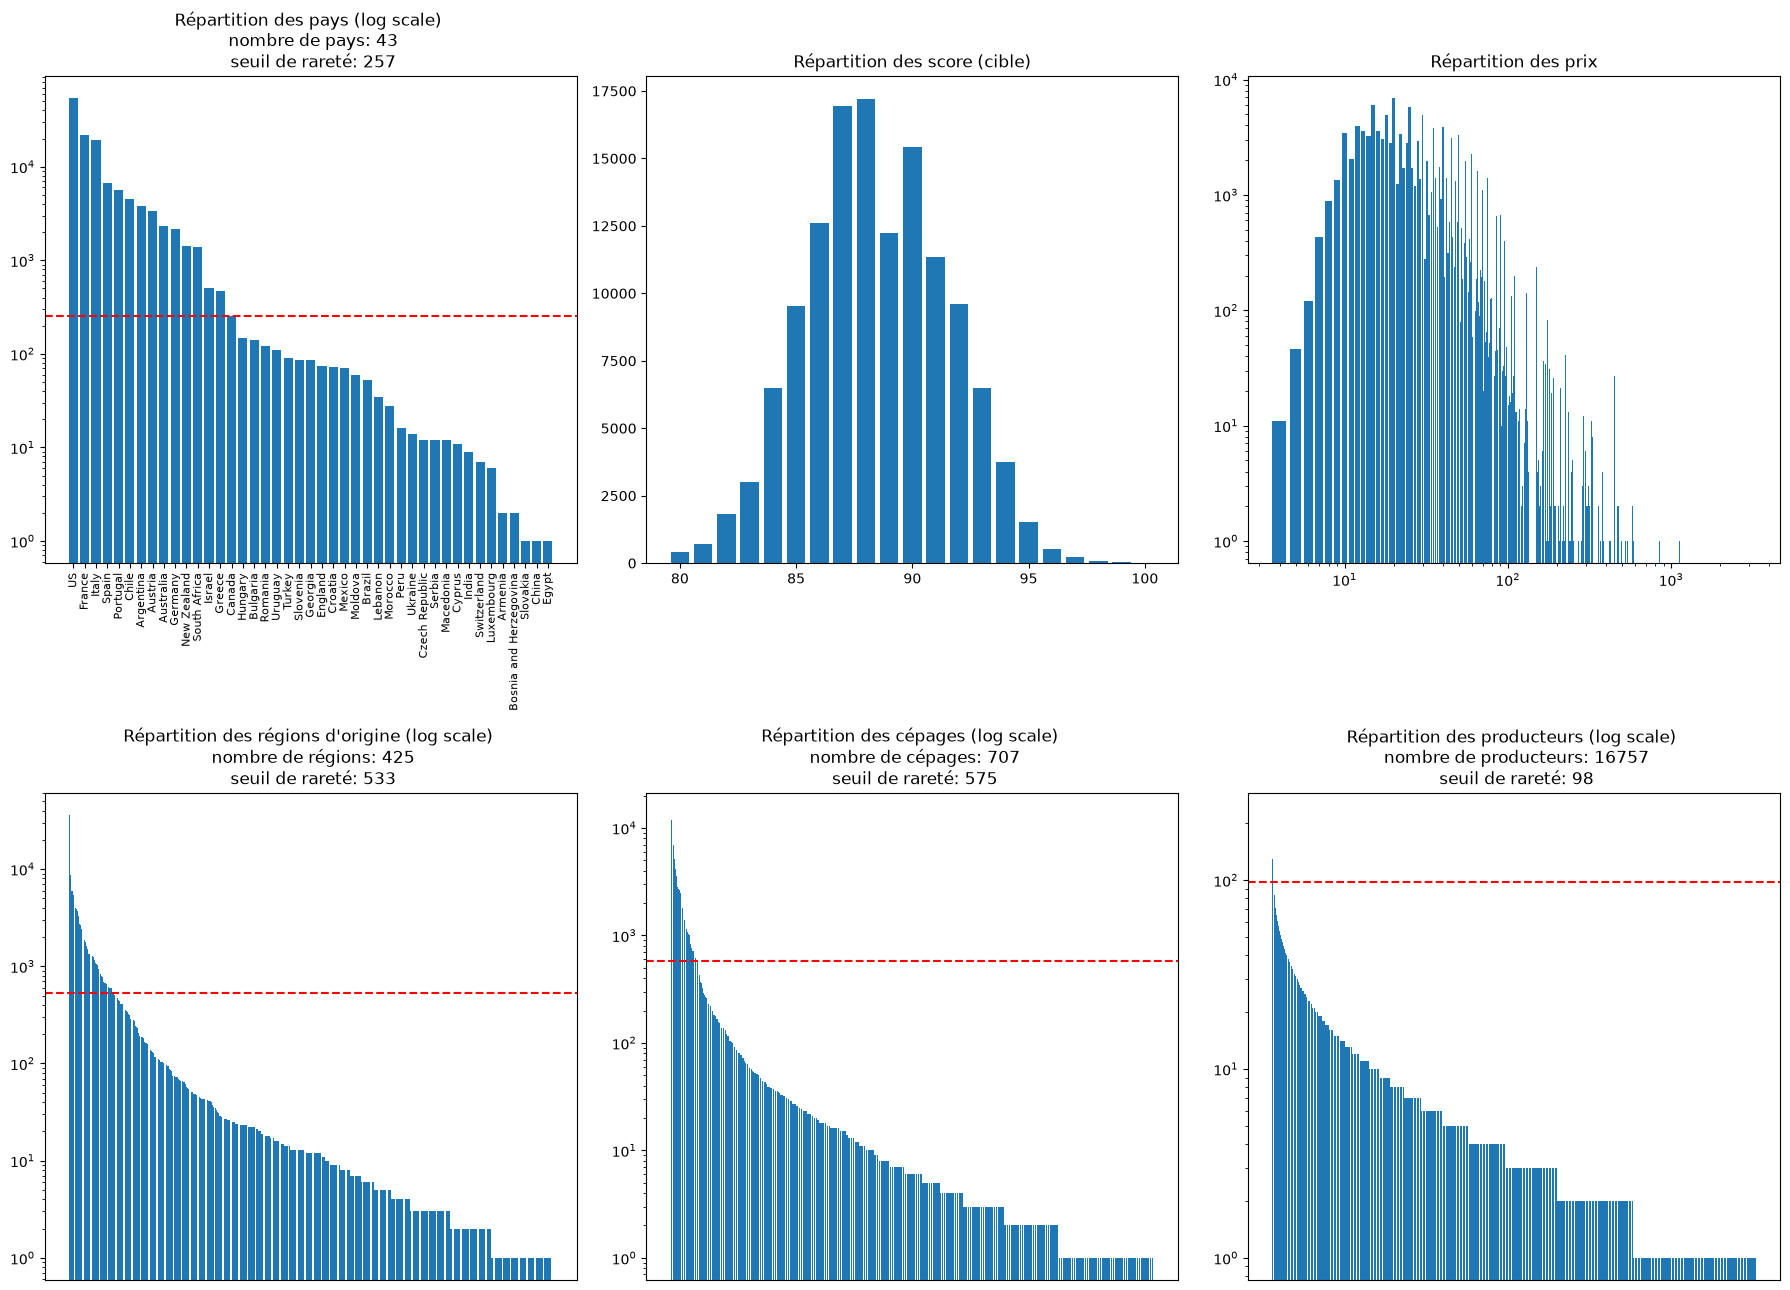

In [14]:
plt.figure(figsize=(18,13))

plt.subplot(2,3,1)
plt.bar(df['country'].value_counts().index, df['country'].value_counts())
plt.yscale("log")
plt.xticks(rotation=90, fontsize=8)
plt.axhline(
    y=MIN_COUNTRY,
    color='red',
    linestyle='--'
)
plt.title("Répartition des pays (log scale) \n nombre de pays: " + str(df['country'].nunique()) + "\n seuil de rareté: " + str(MIN_COUNTRY))


plt.subplot(2,3,2)
plt.bar(df['points'].value_counts().index, df['points'].value_counts())
plt.title("Répartition des score (cible)")

plt.subplot(2,3,3)
plt.bar(df['price'].value_counts().index, df['price'].value_counts())
plt.title("Répartition des prix")
plt.yscale("log")
plt.xscale("log")

plt.subplot(2,3,4)
plt.bar(df['province'].value_counts().index, df['province'].value_counts())
plt.yscale("log")
plt.xticks([])
plt.axhline(
    y=MIN_PROVINCE,
    color='red',
    linestyle='--'
)
plt.title("Répartition des régions d'origine (log scale) \n nombre de régions: " + str(df['province'].nunique()) + "\n seuil de rareté: " + str(MIN_PROVINCE))


plt.subplot(2,3,5)
plt.bar(df['variety'].value_counts().index, df['variety'].value_counts())
plt.yscale("log")
plt.xticks([])
plt.axhline(
    y=MIN_VARIETY,
    color='red',
    linestyle='--'
)
plt.title("Répartition des cépages (log scale) \n nombre de cépages: " + str(df['variety'].nunique()) + "\n seuil de rareté: " + str(MIN_VARIETY))


plt.subplot(2,3,6)
plt.bar(df['winery'].value_counts().index, df['winery'].value_counts())
plt.yscale("log")
plt.axhline(
    y=MIN_WINERY,
    color='red',
    linestyle='--'
)
plt.title("Répartition des producteurs (log scale) \n nombre de producteurs: " + str(df['winery'].nunique()) + "\n seuil de rareté: " + str(MIN_WINERY))
plt.xticks([])

plt.tight_layout()





In [15]:
print("charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques")

for s in df.columns:
    print("< " + s + " >  | " + str(df[s].isna().sum()) + " | " + str(round(df[s].isna().sum()/df.shape[0]*100, 2)) + "% | " + str(df[s].nunique()))



charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques
< id >  | 0 | 0.0% | 129971
< country >  | 63 | 0.05% | 43
< description >  | 0 | 0.0% | 119955
< designation >  | 37465 | 28.83% | 37976
< points >  | 0 | 0.0% | 21
< price >  | 8996 | 6.92% | 390
< province >  | 63 | 0.05% | 425
< region_1 >  | 21247 | 16.35% | 1229
< region_2 >  | 79460 | 61.14% | 17
< taster_name >  | 26244 | 20.19% | 19
< taster_twitter_handle >  | 31213 | 24.02% | 15
< title >  | 0 | 0.0% | 118840
< variety >  | 1 | 0.0% | 707
< winery >  | 0 | 0.0% | 16757


"taster_twitter_handle" est inutile ici
<br>"designation" présente trop de valeur vide + trop différentes.
<br>"title" est le nom du vin, trop de valeurs différentes ici
<br>"region_2" présente trop de valeur absente et "region_1" n'est qu'une précision sur "province" qui présente déjà beacoup de valeurs
<br>"id" ne peut pas non plus être donné au modèle

In [16]:
df = df.drop(columns=['designation', 'taster_twitter_handle', 'title','region_2','region_1','id'])

On va regrouper les valeur de charactéristiques les plus rares et remplacer les valeurs manquantes:

In [17]:
nb_lignes_pays_rares = df['country'].value_counts().loc[lambda counts: counts < MIN_COUNTRY].sum()
print("Nombre de lignes correspondant aux pays rares :", nb_lignes_pays_rares)

nb_lignes_province_rares = df['province'].value_counts().loc[lambda counts: counts < MIN_PROVINCE].sum()
print("Nombre de lignes correspondant aux régions rares :", nb_lignes_province_rares)

nb_lignes_variety_rares = df['variety'].value_counts().loc[lambda counts: counts < MIN_VARIETY].sum()
print("Nombre de lignes correspondant aux cépages rares :", nb_lignes_variety_rares)

nb_lignes_winery_rares = df['winery'].value_counts().loc[lambda counts: counts < MIN_WINERY].sum()
print("Nombre de lignes correspondant aux producteurs rares :", nb_lignes_winery_rares)

Nombre de lignes correspondant aux pays rares : 1276
Nombre de lignes correspondant aux régions rares : 15834
Nombre de lignes correspondant aux cépages rares : 18173
Nombre de lignes correspondant aux producteurs rares : 124549


Même en les regroupant, il y a trop de producteurs, on va donc les retirer

In [18]:
df = df.drop(columns=['winery'])

In [19]:
df["country"] = df["country"].mask(df["country"].isin(df["country"].value_counts()[df["country"].value_counts() < MIN_COUNTRY].index))
df["province"] = df["province"].mask(df["province"].isin(df["province"].value_counts()[df["province"].value_counts() < MIN_PROVINCE].index))
df["variety"] = df["variety"].mask(df["variety"].isin(df["variety"].value_counts()[df["variety"].value_counts() < MIN_VARIETY].index))

In [20]:
df["country"] = df["country"].fillna("Othercountry")
df["province"] = df["province"].fillna("Otherprovince")
df["variety"] = df["variety"].fillna("Othervariety")

df["taster_name"] = df["taster_name"].fillna("Othertaster")
# ON REMPLACE LES VALEURS MANQUANTES DU PRIX PAR LA MOYENNE DES PRIX
df["price"] = df["price"].fillna(format(df["price"].mean(), ".1f"))

#POUR L'INSTANT ON SUPPRIME LES DESCRIPTIONS
df = df.drop(columns=['description'])

In [21]:
print("charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques")

for s in df.columns:
    print("< " + s + " >  | " + str(df[s].isna().sum()) + " | " + str(round(df[s].isna().sum()/df.shape[0]*100, 2)) + "% | " + str(df[s].nunique()))


charactéristique | nombre de valeurs manquantes | pourcentage | nombre de valeurs uniques
< country >  | 0 | 0.0% | 16
< points >  | 0 | 0.0% | 21
< price >  | 0 | 0.0% | 391
< province >  | 0 | 0.0% | 41
< taster_name >  | 0 | 0.0% | 20
< variety >  | 0 | 0.0% | 41


In [22]:
df.to_csv("data/wine_cleaned_no_desc.csv", index=False)

----------------------
## Premiers algos

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import tqdm 
import xgboost as xgb

In [24]:
df = pd.read_csv("data/wine_cleaned_no_desc.csv")

X=np.concatenate([df.values[:,0].reshape(-1,1), df.values[:,3:]], axis=1)
X_prix=df.values[:,2].reshape(-1,1)
Y=df.values[:,1].reshape(-1,1)


One_hot_encoding pour les descripteurs qui en ont besoins:

In [25]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


X = enc.fit_transform(X)
X = np.concatenate([X, X_prix], axis=1)
# print("Catégories trouvées, colonne par colonne: \n", enc.categories_)
print("Echantillon transformé: \n", X[0,:], Y[0])


Echantillon transformé: 
 [0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0
 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 35.4] [87]


Split en 2 jeu: train et test:

In [26]:
Xtrain, Xtest, Ytrain, Ytest = sklearn.model_selection.train_test_split(X, Y, test_size=0.1, random_state=42)

In [27]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error

param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [5, 7, 10],
    'subsample': [0.6, 0.8, 1.0],
}

gs = GridSearchCV(
    estimator=xgb.XGBRegressor(random_state=42, n_jobs=1),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True,
)
gs.fit(Xtrain, Ytrain)

print("Meilleurs paramètres :", gs.best_params_)
print(f"RMSE CV : {-gs.best_score_:.2f}")

# Évaluation unique sur le test, avec le meilleur modèle (déjà réentraîné sur tout Xtrain)
y_pred = gs.best_estimator_.predict(Xtest).ravel()
rmse = np.sqrt(mean_squared_error(Ytest, y_pred))
print(f"RMSE test : {rmse:.2f}")

# Tableau de tous les essais
resultats = (
    pd.DataFrame(gs.cv_results_)
    .assign(rmse=lambda d: -d['mean_test_score'])
    .sort_values('rmse')
    [['params', 'rmse', 'std_test_score']]
)
print(resultats.head(10))

Fitting 5 folds for each of 81 candidates, totalling 405 fits


BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.

In [28]:
from sklearn.metrics import mean_squared_error


bst = xgb.XGBRegressor(learning_rate=0.05, max_depth=7, n_estimators=500, subsample=0.6, random_state=42)
bst.fit(Xtrain, Ytrain)
y_pred = bst.predict(Xtest)


y_pred = bst.predict(Xtest).ravel()

rmse = np.sqrt(mean_squared_error(Ytest, y_pred))
print(f"RMSE: {rmse:.2f}")


RMSE: 2.21


[[80.         82.58863068]
 [80.         82.68965912]
 [80.         82.71030426]
 [80.         82.79143524]
 [80.         82.83196259]
 [80.         82.90386963]
 [80.         83.01013184]
 [80.         83.07292175]
 [80.         83.07620239]
 [80.         83.09598541]]


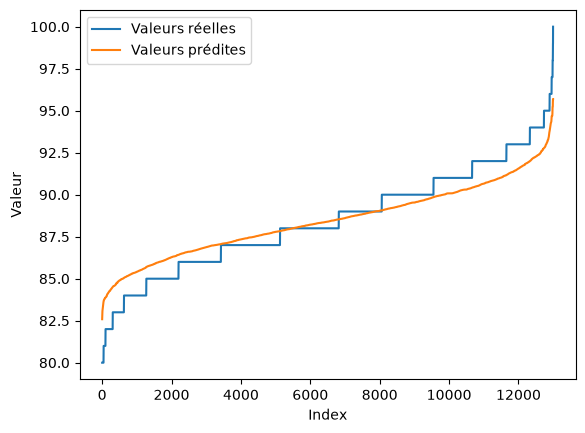

In [29]:
linked = np.sort(np.array([[yt[0],yp] for yt, yp in zip(Ytest, y_pred)]),axis=0)
print(linked[:10])


plt.plot(linked[:, 0], label="Valeurs réelles")
plt.plot(linked[:, 1], label="Valeurs prédites")


plt.xlabel("Index")
plt.ylabel("Valeur")
plt.legend()
plt.show()


----------------------
## Ajout de la description

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import tqdm 
import xgboost as xgb
from sklearn.feature_extraction.text import CountVectorizer

# pip install spacy
# python -m spacy download en_core_web_sm
import spacy

In [31]:
df_full = pd.read_csv("data/winemag-data-130k-v2.csv")
df_cleaned = pd.read_csv("data/wine_cleaned_no_desc.csv")

desc_brut = df_full['description'].values
print("Nombre de descriptions :", len(desc_brut), "longueur moyenne:", np.mean([len(d) for d in desc_brut]), "caractères")

Nombre de descriptions : 129971 longueur moyenne: 242.60106485292874 caractères


In [32]:
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def garder_noms_adjectifs(texte):
    doc = nlp(texte.lower())
    return " ".join(
        tok.lemma_ for tok in doc
        if tok.pos_ in {"NOUN", "ADJ"} and tok.is_alpha
    )
desc =  [garder_noms_adjectifs(d) for d in tqdm.tqdm(desc_brut, desc="Traitement des descriptions")]

print("Nombre de descriptions traitées :", len(desc), "longueur moyenne:", np.mean([len(d) for d in desc]), "caractères")

Traitement des descriptions: 100%|██████████| 129971/129971 [37:53<00:00, 57.18it/s] 

Nombre de descriptions traitées : 129971 longueur moyenne: 127.08242607966392 caractères


In [33]:
print("Nombre de descriptions :", len(desc_brut), "longueur moyenne:", np.mean([len(d) for d in desc_brut]), "caractères")
print("Nombre de descriptions traitées :", len(desc), "longueur moyenne:", np.mean([len(d) for d in desc]), "caractères")

Nombre de descriptions : 129971 longueur moyenne: 242.60106485292874 caractères
Nombre de descriptions traitées : 129971 longueur moyenne: 127.08242607966392 caractères


In [34]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(desc)
mots = vectorizer.get_feature_names_out()
print("Nombre de mots uniques dans les descriptions :", len(mots))
counts = np.asarray(X.sum(axis=0)).ravel()
mots_counts = pd.DataFrame({'mot': mots, 'count': counts}).sort_values(by='count', ascending=False)


Nombre de mots uniques dans les descriptions : 18295


On a filtré les description de manière à ne garder que les noms et adjectifs, trié par nombres d'apparition decroissants:

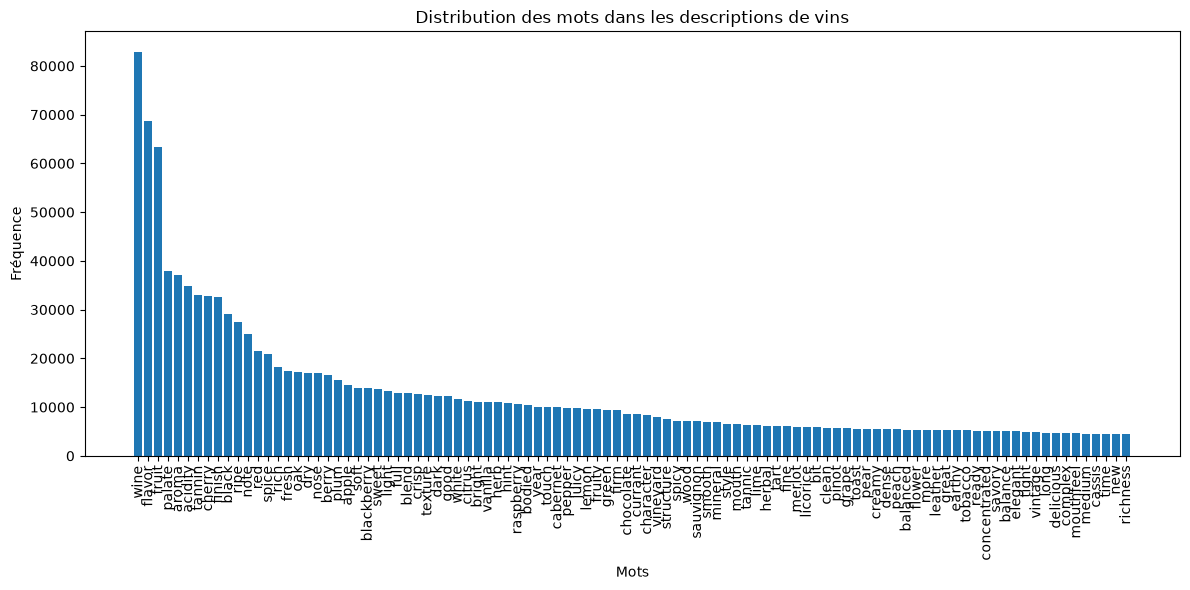

In [35]:
plt.figure(figsize=(12, 6))
plt.bar(mots_counts['mot'][:100], mots_counts['count'][:100])
plt.xlabel("Mots")
plt.ylabel("Fréquence")
plt.title("Distribution des mots dans les descriptions de vins")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [36]:
NB_MOT = 100
mots_to_keep = mots_counts['mot'][:NB_MOT].values

for m in tqdm.tqdm(mots_to_keep, desc="Création des colonnes pour les mots"):
    df_cleaned[m] = [1 if m in d else 0 for d in desc]



Création des colonnes pour les mots:  96%|█████████▌| 96/100 [00:04<00:00, 23.11it/s]C:\Users\alexs\AppData\Local\Temp\ipykernel_32112\2423882247.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cleaned[m] = [1 if m in d else 0 for d in desc]
Création des colonnes pour les mots:  99%|█████████▉| 99/100 [00:04<00:00, 22.69it/s]C:\Users\alexs\AppData\Local\Temp\ipykernel_32112\2423882247.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_cleaned[m] = [1 if m in d else 0 for d in desc]
Création des colonnes pour les mots:

In [37]:
df_cleaned.to_csv("data/wine_cleaned_with_desc.csv", index=False)

------------------
## Algos avec desc

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import pandas as pd
import tqdm 
import xgboost as xgb

In [15]:
df = pd.read_csv("data/wine_cleaned_with_desc.csv")
mots_kept = df.columns[6:]
X = np.concatenate([df.values[:,0].reshape(-1,1), df.values[:,3:6]], axis=1)
X_prix=df.values[:,2].reshape(-1,1)
X_desc=df.values[:,6:]
Y=df.values[:,1].reshape(-1,1)


In [3]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False)


X = enc.fit_transform(X)
X = np.concatenate([X, X_prix, X_desc], axis=1)
print("Catégories trouvées, colonne par colonne: \n", enc.categories_)
print("Echantillon transformé: \n", X[0,:], Y[0])

Catégories trouvées, colonne par colonne: 
 [array(['Argentina', 'Australia', 'Austria', 'Canada', 'Chile', 'France',
       'Germany', 'Greece', 'Israel', 'Italy', 'New Zealand',
       'Othercountry', 'Portugal', 'South Africa', 'Spain', 'US'],
      dtype=object), array(['Alentejano', 'Alsace', 'Beaujolais', 'Bordeaux', 'Burgenland',
       'Burgundy', 'California', 'Casablanca Valley', 'Catalonia',
       'Central Italy', 'Champagne', 'Colchagua Valley', 'Douro',
       'France Other', 'Languedoc-Roussillon', 'Loire Valley', 'Lombardy',
       'Maipo Valley', 'Marlborough', 'Mendoza Province', 'Mosel',
       'New York', 'Niederösterreich', 'Northeastern Italy',
       'Northern Spain', 'Oregon', 'Other', 'Otherprovince', 'Piedmont',
       'Port', 'Provence', 'Rhône Valley', 'Sicily & Sardinia',
       'South Australia', 'Southern Italy', 'Southwest France', 'Tejo',
       'Tuscany', 'Veneto', 'Virginia', 'Washington'], dtype=object), array(['Alexander Peartree', 'Anna Lee C. Iiji

In [4]:
Xtrain, Xtest, Ytrain, Ytest = sklearn.model_selection.train_test_split(X, Y, test_size=0.1, random_state=42)

In [5]:
from sklearn.metrics import mean_squared_error


bst = xgb.XGBRegressor(learning_rate=0.05, max_depth=7, n_estimators=500, subsample=0.6, random_state=42)
bst.fit(Xtrain, Ytrain)
y_pred = bst.predict(Xtest)


y_pred = bst.predict(Xtest).ravel()

rmse = np.sqrt(mean_squared_error(Ytest, y_pred))
print(f"RMSE: {rmse:.2f}")

RMSE: 1.81


[[80.         81.12532806]
 [80.         81.47084045]
 [80.         81.60884094]
 [80.         81.68587494]
 [80.         81.74956512]
 [80.         81.80691528]
 [80.         81.86331177]
 [80.         81.89532471]
 [80.         81.90827942]
 [80.         81.91281891]]


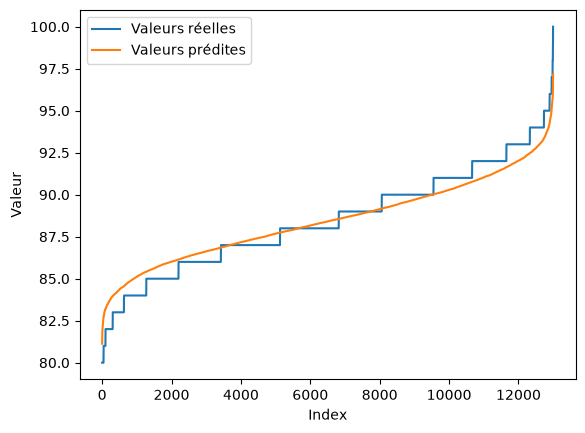

In [6]:
linked = np.sort(np.array([[yt[0],yp] for yt, yp in zip(Ytest, y_pred)]),axis=0)
print(linked[:10])


plt.plot(linked[:, 0], label="Valeurs réelles")
plt.plot(linked[:, 1], label="Valeurs prédites")


plt.xlabel("Index")
plt.ylabel("Valeur")
plt.legend()
plt.show()

(129971, 4)
118
1


<Axes: >

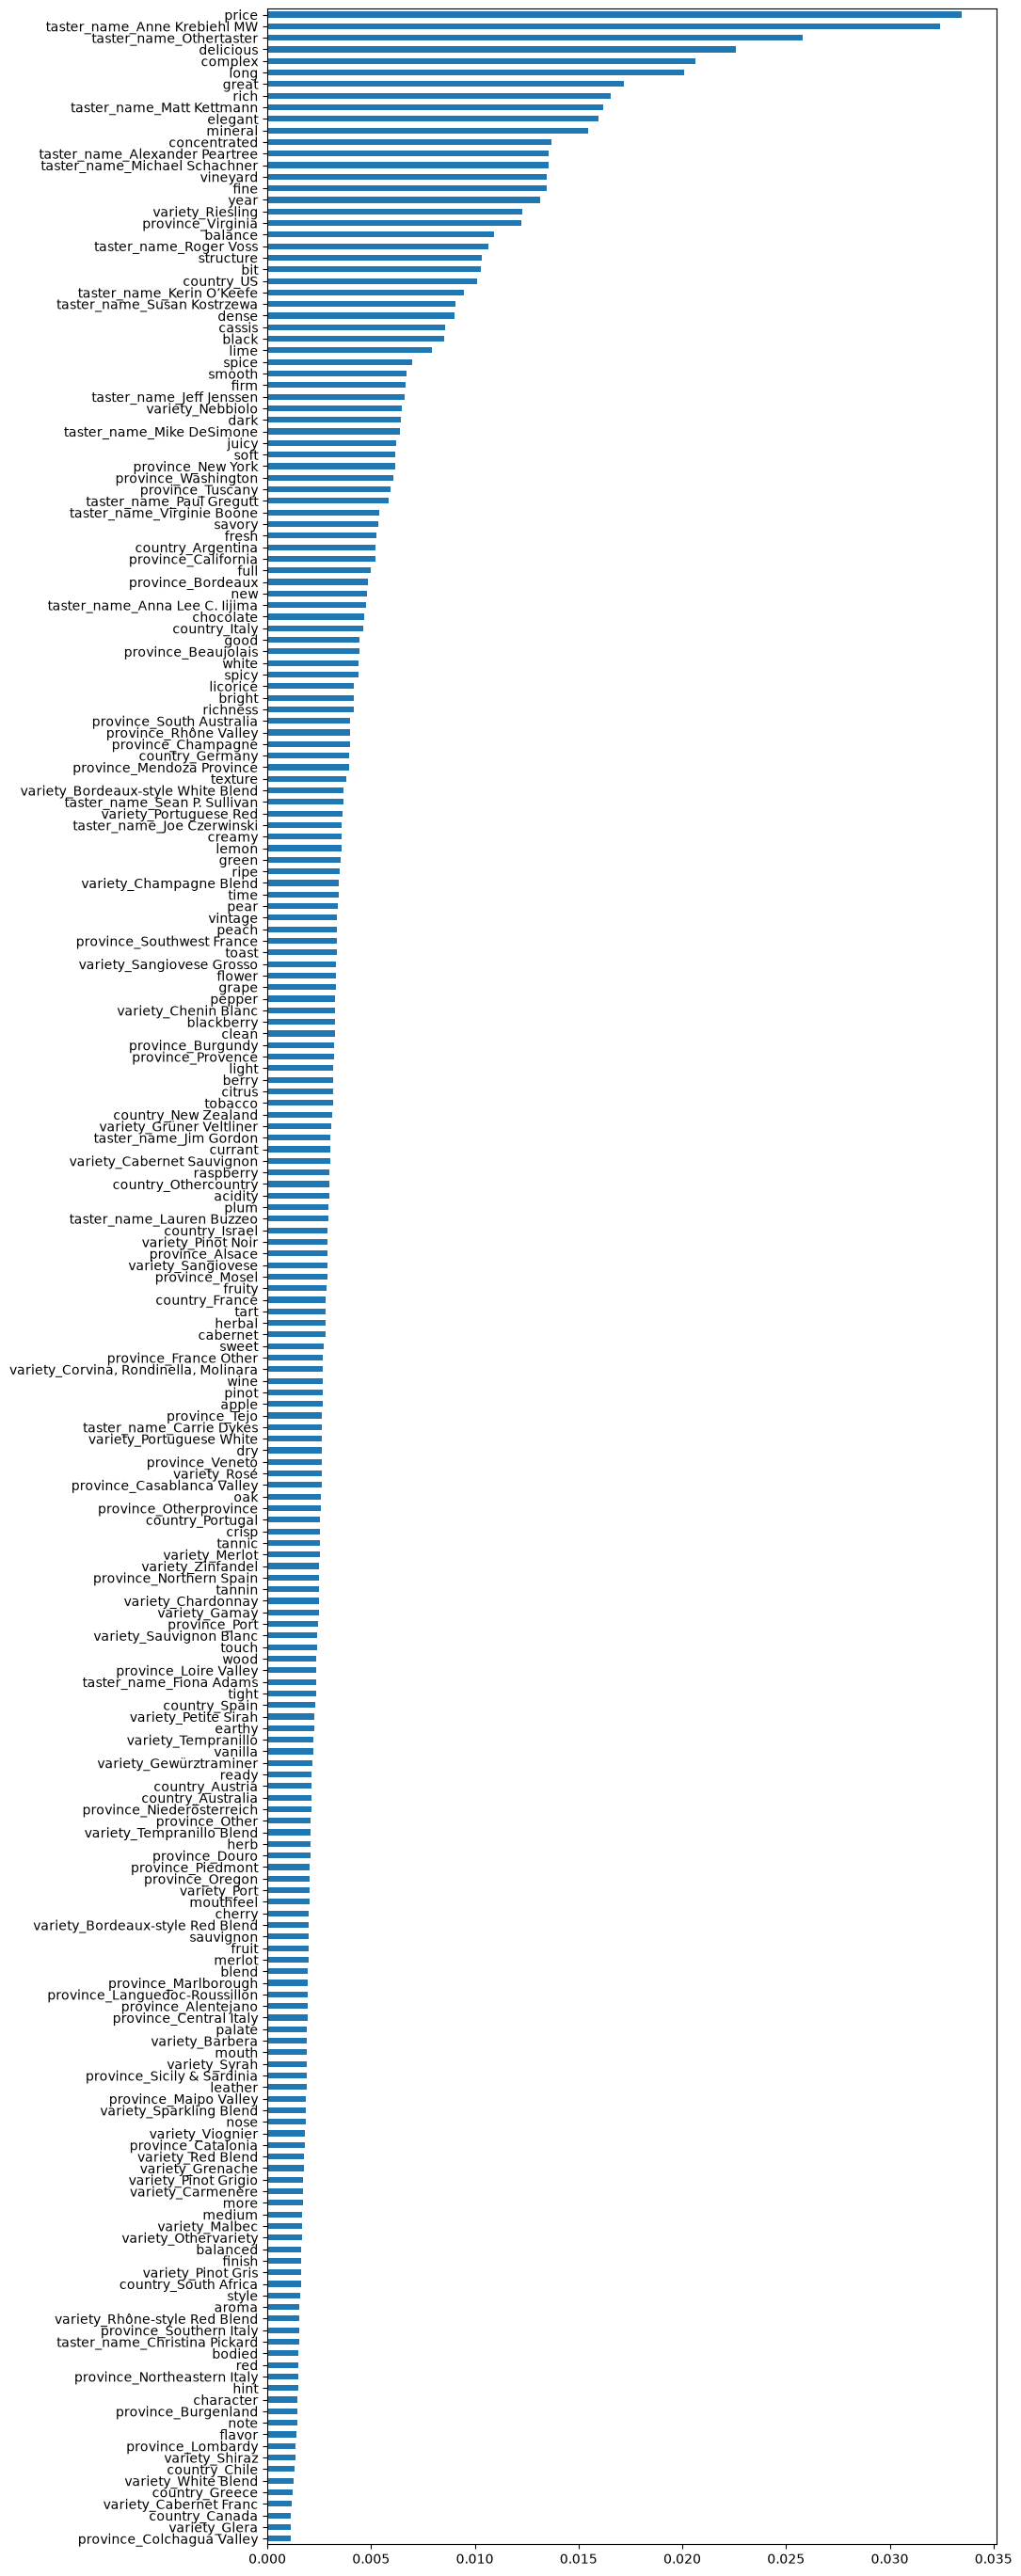

In [ ]:
categories = enc.categories_[0].tolist() + enc.categories_[1].tolist() + enc.categories_[2].tolist() + enc.categories_[3].tolist()

cat_cols = [df.columns[0]] + df.columns[3:6].tolist()
feature_names = (enc.get_feature_names_out(cat_cols).tolist()
                 + [df.columns[2]]
                 + mots_kept.tolist())

importances = pd.Series(
    bst.feature_importances_,
    index = feature_names
).sort_values()


importances.plot.barh(figsize=(10, 35))

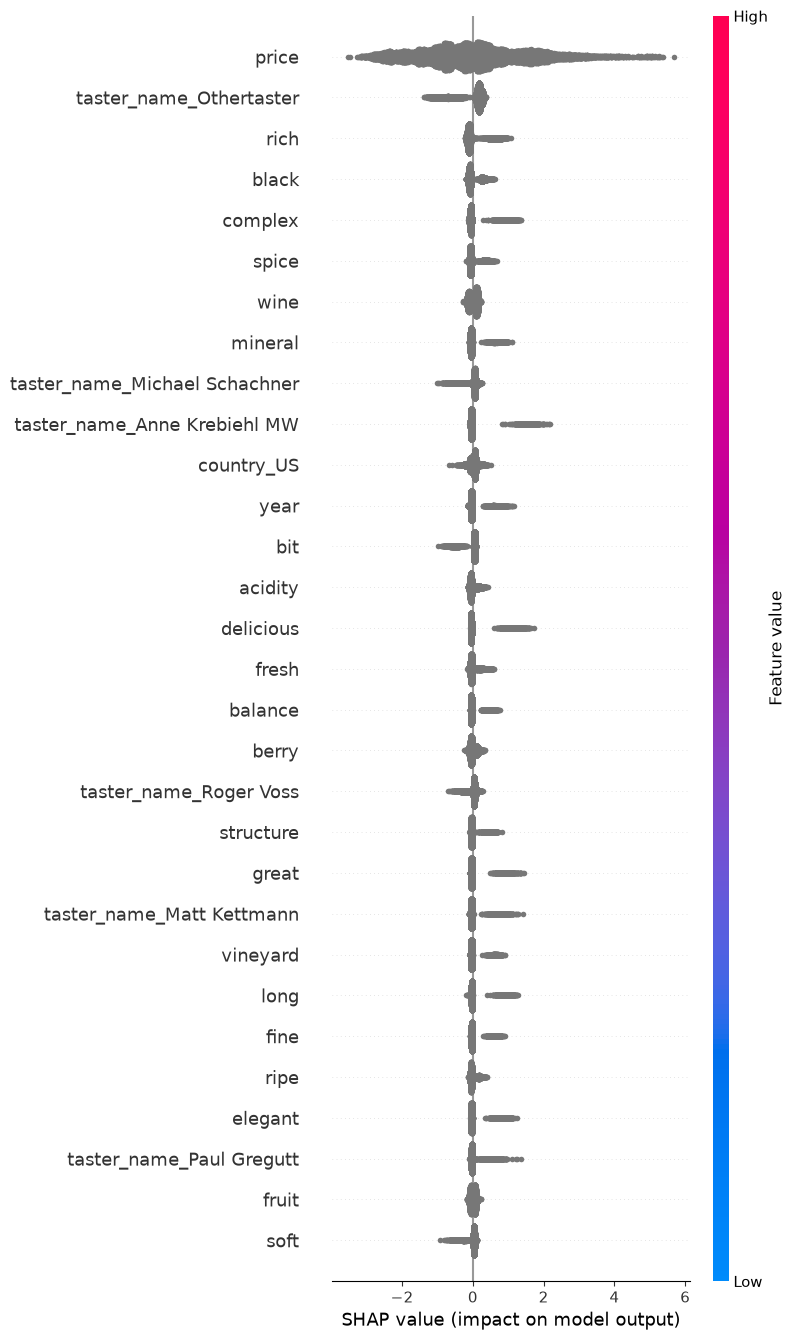

In [17]:
import shap
explainer = shap.TreeExplainer(bst)
sv = explainer.shap_values(Xtest)

Xtest_df = pd.DataFrame(Xtest, columns=feature_names)
shap.summary_plot(sv, Xtest_df, max_display=30)

In [19]:
sv_df = pd.DataFrame(sv, columns=feature_names)

table = pd.DataFrame({
    "mean_abs_shap": sv_df.abs().mean(),
    "mean_shap_when_present": [
        sv_df[c][Xtest_df[c] > 0].mean() if (Xtest_df[c] > 0).any() else np.nan
        for c in feature_names
    ],
    "n_present": (Xtest_df > 0).sum(),
}).sort_values("mean_abs_shap", ascending=False)

print(table.head(30))

                               mean_abs_shap  mean_shap_when_present  \
price                               1.157509                0.005034   
taster_name_Othertaster             0.300944               -0.743532   
rich                                0.199742                0.615404   
black                               0.142719                0.286442   
complex                             0.121492                0.920759   
spice                               0.112035                0.351144   
wine                                0.102218                0.101092   
mineral                             0.099574                0.628229   
taster_name_Michael Schachner       0.096968               -0.393499   
taster_name_Anne Krebiehl MW        0.095257                1.549518   
country_US                          0.091536               -0.092330   
year                                0.088906                0.599212   
bit                                 0.084620               -0.52